In [1]:
# AI Study Assistant

## Module 6 : Model Training

### Objectives

#- Load processed dataset
#- Train Machine Learning models
#- Compare different algorithms
# Select the best model

In [2]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
import pandas as pd

ap_df = pd.read_csv(
    r"C:\Users\ABC\Desktop\DATASET\dataset\processed\updated_antennas_dataset.csv"
)

es_df = pd.read_csv(
    r"C:\Users\ABC\Desktop\DATASET\dataset\processed\updated_embedded_dataset.csv"
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
df = pd.concat([ap_df, es_df], ignore_index=True)

print(df.shape)

(924, 10)


In [5]:
print(df.columns.tolist())

['Question', 'Subject', 'Chapter', 'Years_Appeared', 'Frequency', 'Average_Marks', 'Unnamed: 6', 'Priority', 'Is_Augmented', 'Source_Question']


In [6]:
# Remove unwanted column if it exists

if "Unnamed: 6" in df.columns:
    df.drop(columns=["Unnamed: 6"], inplace=True)

print(df.columns.tolist())

['Question', 'Subject', 'Chapter', 'Years_Appeared', 'Frequency', 'Average_Marks', 'Priority', 'Is_Augmented', 'Source_Question']


In [7]:
# Feature (Input)
X = df["Question"].fillna("").astype(str)

# Target (Output)
y = df["Priority"]

print("Features Created Successfully")
print("Total Samples :", len(X))

Features Created Successfully
Total Samples : 924


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(X)

print("Vectorization Completed")
print("Shape :", X.shape)

Vectorization Completed
Shape : (924, 1865)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (739, 1865)
Testing Samples : (185, 1865)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Save Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:",
      round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 96.22 %


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

# Save Accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:",
      round(nb_accuracy*100,2), "%")

Naive Bayes Accuracy: 95.14 %


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Save accuracy in a variable
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 96.76 %


In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 96.76 %


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "SVM"
    ],
    "Accuracy (%)": [
        round(lr_accuracy*100,2),
        round(nb_accuracy*100,2),
        round(rf_accuracy*100,2),
        round(svm_accuracy*100,2)
    ]
})

print(results)

                 Model  Accuracy (%)
0  Logistic Regression         96.22
1          Naive Bayes         95.14
2        Random Forest         96.76
3                  SVM         96.76


In [22]:
best_model = results.loc[results["Accuracy (%)"].idxmax()]

print("Best Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy (%)"], "%")

Best Model : Random Forest
Accuracy : 96.76 %


In [23]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

        High       0.93      1.00      0.96        82
         Low       1.00      1.00      1.00        86
      Medium       1.00      0.65      0.79        17

    accuracy                           0.97       185
   macro avg       0.98      0.88      0.92       185
weighted avg       0.97      0.97      0.96       185



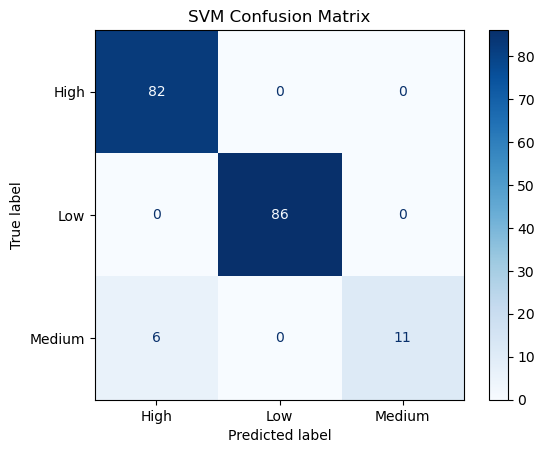

In [40]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [26]:
train_accuracy = accuracy_score(
    y_train,
    svm_model.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print("Training Accuracy :", round(train_accuracy*100,2), "%")
print("Testing Accuracy :", round(test_accuracy*100,2), "%")

Training Accuracy : 100.0 %
Testing Accuracy : 96.76 %


In [27]:
gap = train_accuracy - test_accuracy

print("Accuracy Gap :", round(gap*100,2), "%")

if gap < 0.05:
    print("Excellent Model ✅")
elif gap < 0.15:
    print("Slight Overfitting ⚠️")
else:
    print("Overfitting ❌")

Accuracy Gap : 3.24 %
Excellent Model ✅


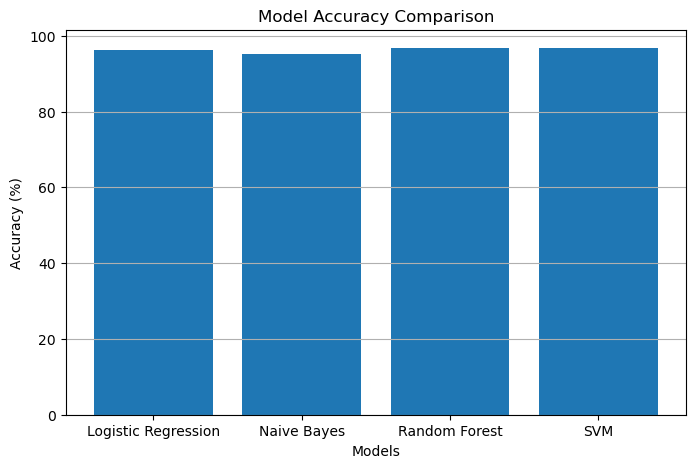

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.grid(axis="y")

plt.show()

In [29]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model Comparison Saved Successfully")

Model Comparison Saved Successfully


In [30]:
print("="*50)
print("MODULE 6 COMPLETED")
print("="*50)


print("Best Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy (%)"], "%")

MODULE 6 COMPLETED
Best Model : Random Forest
Accuracy : 96.76 %


In [31]:
print("lr_model :", "lr_model" in globals())
print("nb_model :", "nb_model" in globals())
print("rf_model :", "rf_model" in globals())
print("svm_model:", "svm_model" in globals())

lr_model : True
nb_model : True
rf_model : True
svm_model: True


In [32]:
import pickle
import os

In [33]:
os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [34]:
with open("../models/study_assistant_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

print("Model Saved Successfully")

Model Saved Successfully


In [35]:
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Vectorizer Saved Successfully")

Vectorizer Saved Successfully


In [36]:
with open("../models/study_assistant_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully")

Model Loaded Successfully


In [37]:
with open("../models/tfidf_vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

print("Vectorizer Loaded Successfully")

Vectorizer Loaded Successfully


In [38]:
question = "Explain the working principle of patch antenna."

question_vector = loaded_vectorizer.transform([question])

prediction = loaded_model.predict(question_vector)

print("Predicted Difficulty :", prediction[0])

Predicted Difficulty : High


In [39]:
import os

print(os.listdir("../models"))

['best_model.pkl', 'label_encoder.pkl', 'study_assistant_model.pkl', 'tfidf_vectorizer.pkl']
